## __Data Science Capstone — Part 2: Lightning Talk 2__
# Real Estate Price Prediction

**Data Source:** [King County House Sales — Kaggle](https://www.kaggle.com/datasets/harlfoxem/housesalesprediction)

This notebook is organized end-to-end: problem framing → data dictionary → cleaning → EDA →
feature engineering → **trying several models in different ways** (raw target vs. log target,
linear vs. regularized vs. tree ensembles) → hyperparameter tuning → picking the best model.

## Problem Statement
House prices fluctuate significantly, and buyers and sellers may face substantially different
property prices depending on factors such as living area, number of bedrooms, bathrooms, location,
house condition, grade, waterfront view, and year built. These variations make it hard for buyers,
sellers, and agents to know whether a listed price is fair.

**Goal:** build a regression model that predicts a house's sale `price` from its physical and
locational attributes, so that the estimate can serve as a fair-value benchmark.

**Success metrics:** minimize **MAE** and **RMSE** on held-out data while maximizing **R²**.

**Potential audience:** home buyers/sellers, real-estate agents, and mortgage lenders who need a
quick, data-driven price estimate.

## Objectives
- What features influence `price` the most?
- Does feature engineering (house age, renovation flag, studio flag) improve model performance?
- How do different model **families** compare (linear vs. regularized linear vs. tree ensembles)?
- Does predicting `log(price)` instead of raw `price` help, given the skewed target?
- Which model, after tuning, gives the best generalization on unseen data?

**Model type:** Regression (continuous target: `price`)
**Number of models tried:** 6 base algorithms × 2 target transforms = 12 experiments, then the
best candidate is hyperparameter-tuned.
**Evaluation metrics:** MAE, RMSE, R².

# Data Inspection
## Data Dictionary
| Column | Type | Description |
|---|---|---|
| id | int | Unique house identifier |
| date | object | Date the house was sold |
| price | float | **Target.** Sale price |
| bedrooms | int | Number of bedrooms |
| bathrooms | float | Number of bathrooms |
| sqft_living | int | Living space square footage |
| sqft_lot | int | Lot square footage |
| floors | float | Number of floors |
| waterfront | int | 1 if property has a waterfront view |
| view | int | Quality of view (0–4 scale) |
| condition | int | Overall condition rating (1–5) |
| grade | int | Construction/design quality grade |
| sqft_above | int | Square footage above ground |
| sqft_basement | int | Square footage of basement |
| yr_built | int | Year house was built |
| yr_renovated | int | Year renovated (0 if never) |
| zipcode | int | Zip code |
| lat / long | float | Latitude / longitude |
| sqft_living15 | int | Living space of nearest 15 neighbors (avg) |
| sqft_lot15 | int | Lot size of nearest 15 neighbors (avg) |

In [4]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import f_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## Data Overview
Load and inspect the dataset.

In [5]:
df = pd.read_csv('./Data/kc_house_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,"221,900.00",3,1.00,1180,5650,1.00,0,0,...,7,1180,0,1955,0,98178,47.51,-122.26,1340,5650
1,6414100192,20141209T000000,"538,000.00",3,2.25,2570,7242,2.00,0,0,...,7,2170,400,1951,1991,98125,47.72,-122.32,1690,7639
2,5631500400,20150225T000000,"180,000.00",2,1.00,770,10000,1.00,0,0,...,6,770,0,1933,0,98028,47.74,-122.23,2720,8062
3,2487200875,20141209T000000,"604,000.00",4,3.00,1960,5000,1.00,0,0,...,7,1050,910,1965,0,98136,47.52,-122.39,1360,5000
4,1954400510,20150218T000000,"510,000.00",3,2.00,1680,8080,1.00,0,0,...,8,1680,0,1987,0,98074,47.62,-122.05,1800,7503


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [7]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,"21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00"
mean,"4,580,301,520.86","540,088.14",3.37,2.11,"2,079.90","15,106.97",1.49,0.01,0.23,3.41,7.66,"1,788.39",291.51,"1,971.01",84.40,"98,077.94",47.56,-122.21,"1,986.55","12,768.46"
std,"2,876,565,571.31","367,127.20",0.93,0.77,918.44,"41,420.51",0.54,0.09,0.77,0.65,1.18,828.09,442.58,29.37,401.68,53.51,0.14,0.14,685.39,"27,304.18"
min,"1,000,102.00","75,000.00",0.00,0.00,290.00,520.00,1.00,0.00,0.00,1.00,1.00,290.00,0.00,"1,900.00",0.00,"98,001.00",47.16,-122.52,399.00,651.00
25%,"2,123,049,194.00","321,950.00",3.00,1.75,"1,427.00","5,040.00",1.00,0.00,0.00,3.00,7.00,"1,190.00",0.00,"1,951.00",0.00,"98,033.00",47.47,-122.33,"1,490.00","5,100.00"
50%,"3,904,930,410.00","450,000.00",3.00,2.25,"1,910.00","7,618.00",1.50,0.00,0.00,3.00,7.00,"1,560.00",0.00,"1,975.00",0.00,"98,065.00",47.57,-122.23,"1,840.00","7,620.00"
75%,"7,308,900,445.00","645,000.00",4.00,2.50,"2,550.00","10,688.00",2.00,0.00,0.00,4.00,8.00,"2,210.00",560.00,"1,997.00",0.00,"98,118.00",47.68,-122.12,"2,360.00","10,083.00"
max,"9,900,000,190.00","7,700,000.00",33.00,8.00,"13,540.00","1,651,359.00",3.50,1.00,4.00,5.00,13.00,"9,410.00","4,820.00","2,015.00","2,015.00","98,199.00",47.78,-121.31,"6,210.00","871,200.00"


# Data Cleaning
Handle missing values, type conversions, and known data-entry errors.

In [8]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [9]:
df['date'] = pd.to_datetime(df['date'])
df['bathrooms'] = df['bathrooms'].astype(int)
df['floors'] = df['floors'].astype(int)
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,"221,900.00",3,1,1180,5650,1,0,0,...,7,1180,0,1955,0,98178,47.51,-122.26,1340,5650
1,6414100192,2014-12-09,"538,000.00",3,2,2570,7242,2,0,0,...,7,2170,400,1951,1991,98125,47.72,-122.32,1690,7639
2,5631500400,2015-02-25,"180,000.00",2,1,770,10000,1,0,0,...,6,770,0,1933,0,98028,47.74,-122.23,2720,8062
3,2487200875,2014-12-09,"604,000.00",4,3,1960,5000,1,0,0,...,7,1050,910,1965,0,98136,47.52,-122.39,1360,5000
4,1954400510,2015-02-18,"510,000.00",3,2,1680,8080,1,0,0,...,8,1680,0,1987,0,98074,47.62,-122.05,1800,7503


In [10]:
# Known data quality issue: a house with 33 bedrooms and only ~1,620 sqft living area / 1 bathroom
# is almost certainly a typo for 3 bedrooms.
df[df['bedrooms'] == 33][['bedrooms', 'bathrooms', 'sqft_living']]

,bedrooms,bathrooms,sqft_living
15870,33,1,1620


In [11]:
df.loc[df['bedrooms'] == 33, 'bedrooms'] = 3

# Exploratory Data Analysis (EDA)
Target distribution, outliers, and relationships with `price`.

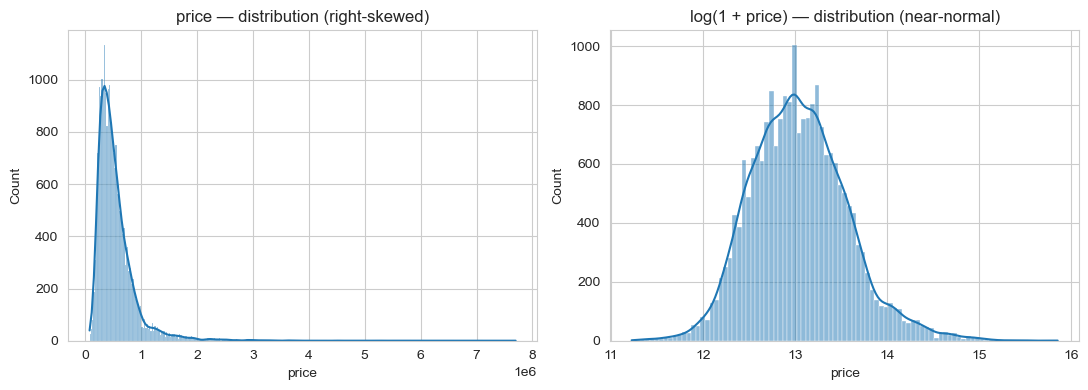

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['price'], kde=True, ax=axes[0])
axes[0].set_title('price — distribution (right-skewed)')
sns.histplot(np.log1p(df['price']), kde=True, ax=axes[1])
axes[1].set_title('log(1 + price) — distribution (near-normal)')
plt.tight_layout()
plt.show()

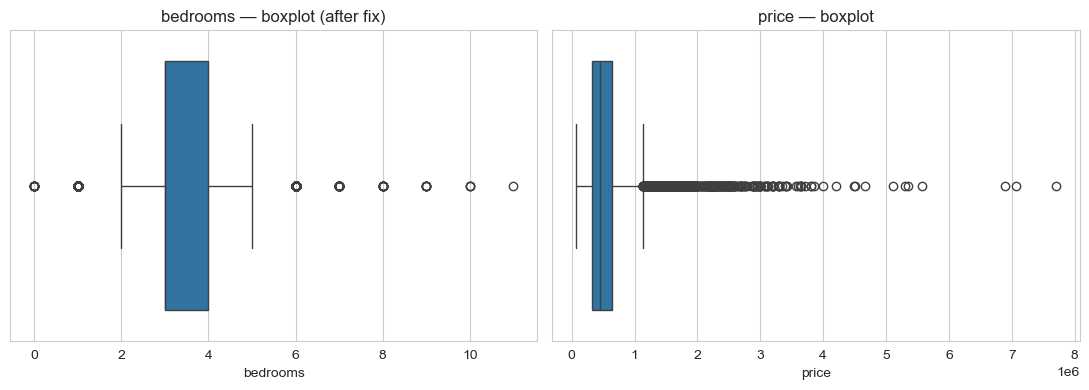

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x=df['bedrooms'], ax=axes[0])
axes[0].set_title('bedrooms — boxplot (after fix)')
sns.boxplot(x=df['price'], ax=axes[1])
axes[1].set_title('price — boxplot')
plt.tight_layout()
plt.show()

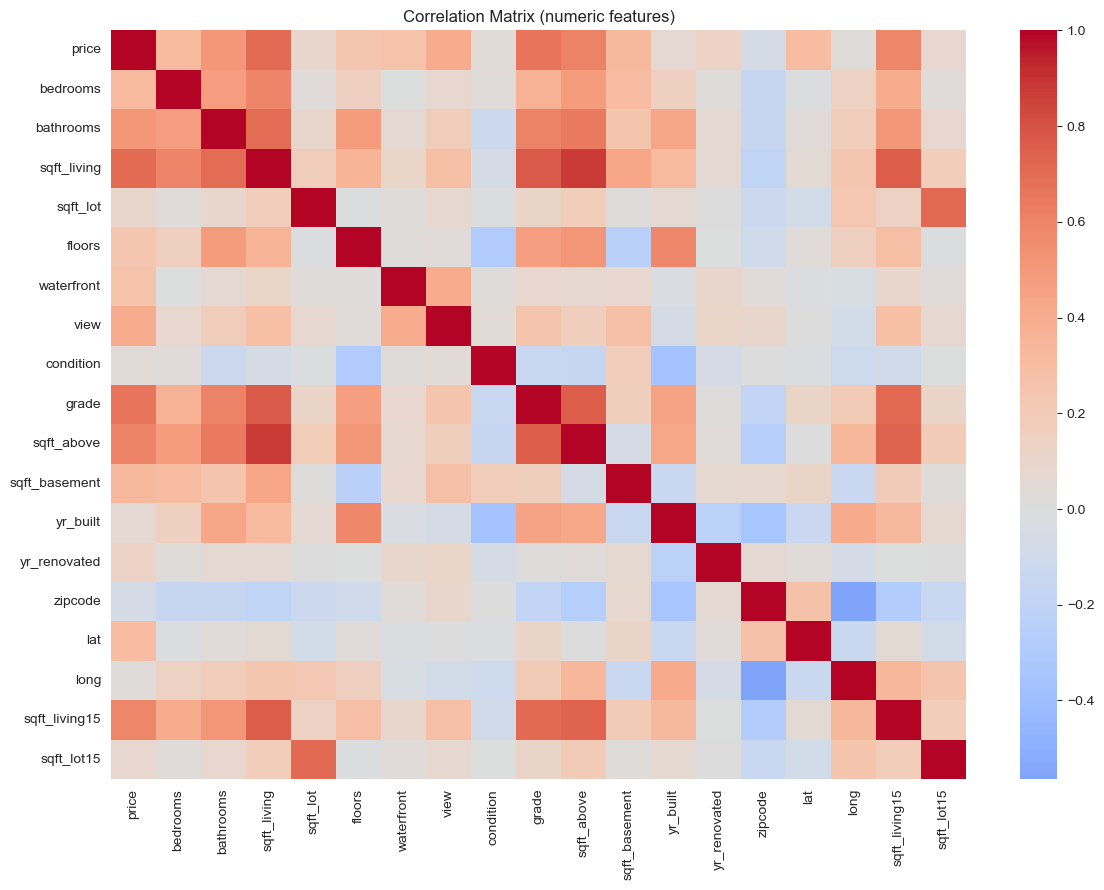

price            1.00
sqft_living      0.70
grade            0.67
sqft_above       0.61
sqft_living15    0.59
bathrooms        0.51
view             0.40
sqft_basement    0.32
bedrooms         0.32
lat              0.31
waterfront       0.27
floors           0.24
yr_renovated     0.13
sqft_lot         0.09
sqft_lot15       0.08
yr_built         0.05
condition        0.04
long             0.02
zipcode         -0.05
Name: price, dtype: float64


In [14]:
num_cols = df.select_dtypes(include=np.number).columns.drop(['id'])
corr = df[num_cols].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Matrix (numeric features)')
plt.tight_layout()
plt.show()

print(corr['price'].sort_values(ascending=False))

### EDA Insight
`sqft_living`, `grade`, and `sqft_above` show the strongest positive correlation with `price`.
Location fields (`lat`, `zipcode`) matter too, but non-linearly — a good sign that tree-based
models may outperform plain linear regression.

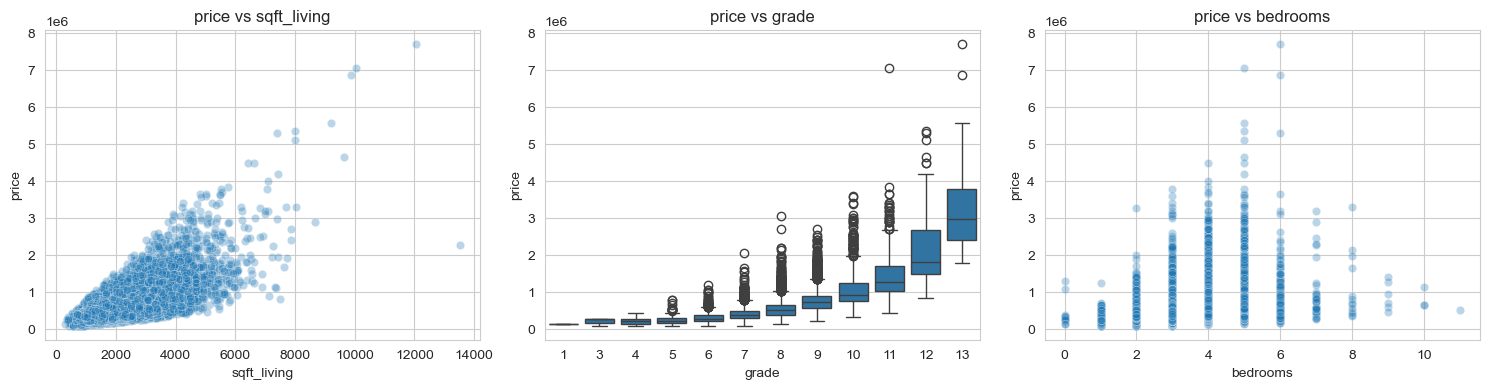

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(x=df['sqft_living'], y=df['price'], alpha=0.3, ax=axes[0])
axes[0].set_title('price vs sqft_living')
sns.boxplot(x=df['grade'], y=df['price'], ax=axes[1])
axes[1].set_title('price vs grade')
sns.scatterplot(x=df['bedrooms'], y=df['price'], alpha=0.3, ax=axes[2])
axes[2].set_title('price vs bedrooms')
plt.tight_layout()
plt.show()

### Insight
Living area and construction grade have clear, roughly monotonic relationships with price.
`bedrooms` is noisier and not perfectly linear — other features (size, location, quality)
explain more of the variance, which again motivates trying non-linear models.

# Feature Engineering
Create a few derived features that a domain expert would expect to matter:
- `house_age`: age of the house at time of sale
- `is_renovated`: whether the house was ever renovated
- `is_studio`: small unit heuristic (0–1 bedrooms and < 600 sqft living)

In [16]:
df['house_age'] = df['date'].dt.year - df['yr_built']
df['is_renovated'] = (df['yr_renovated'] > 0).astype(int)
df['is_studio'] = ((df['bedrooms'].isin([0, 1])) & (df['sqft_living'] < 600)).astype(int)

df[['yr_built', 'date', 'house_age', 'yr_renovated', 'is_renovated', 'is_studio']].head()

,yr_built,date,house_age,yr_renovated,is_renovated,is_studio
0,1955,2014-10-13,59,0,0,0
1,1951,2014-12-09,63,1991,1,0
2,1933,2015-02-25,82,0,0,0
3,1965,2014-12-09,49,0,0,0
4,1987,2015-02-18,28,0,0,0


In [17]:
print(df['is_studio'].value_counts())
print(df.groupby('is_studio')['price'].mean())

is_studio
0    21577
1       36
Name: count, dtype: int64
is_studio
0   540,590.39
1   239,058.33
Name: price, dtype: float64


In [18]:
cat_cols = ['zipcode', 'grade', 'condition', 'view', 'waterfront', 'is_studio', 'is_renovated']
f_values, p_values = f_regression(df[cat_cols], df['price'])
pd.DataFrame({'Feature': cat_cols, 'F-statistic': np.round(f_values, 1), 'p-value': p_values}) \
    .sort_values('F-statistic', ascending=False)

,Feature,F-statistic,p-value
1,grade,"17,360.60",0.00
3,view,"4,050.50",0.00
4,waterfront,"1,650.50",0.00
6,is_renovated,349.20,0.00
0,zipcode,61.30,0.00
2,condition,28.60,0.00
5,is_studio,24.30,0.00


# Modeling
## Evaluation Metrics
- **MAE:** average absolute prediction error (dollars).
- **RMSE:** penalizes large errors more heavily.
- **R²:** proportion of price variance explained by the model.

## Train / Test Split

In [19]:
y = df['price']
X = df.drop(columns=['id', 'date', 'price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training set:', X_train.shape)
print('Testing set: ', X_test.shape)

Training set: (17290, 21)
Testing set:  (4323, 21)


In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Trying Several Models, Several Ways
Strategy: try 6 model families, each on (a) the raw `price` target and (b) the
`log1p(price)` target (to handle the right-skew we saw in the EDA), for **12 experiments total**.
Linear models use the standardized features; tree ensembles use the raw features (scale-invariant).

In [21]:
results = []

def evaluate(name, model, Xtr, Xte, ytr, yte, log_target=False):
    if log_target:
        model.fit(Xtr, np.log1p(ytr))
        pred = np.expm1(model.predict(Xte))
    else:
        model.fit(Xtr, ytr)
        pred = model.predict(Xte)
    mae = mean_absolute_error(yte, pred)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    r2 = r2_score(yte, pred)
    results.append({'Model': name, 'Target': 'log(price)' if log_target else 'price',
                     'MAE': mae, 'RMSE': rmse, 'R2': r2})
    return model

models_raw = {
    'Linear Regression': (LinearRegression(), X_train, X_test),
    'Ridge': (Ridge(alpha=1.0), X_train_scaled, X_test_scaled),
    'Lasso': (Lasso(alpha=100), X_train_scaled, X_test_scaled),
    'Random Forest': (RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1), X_train, X_test),
    'Gradient Boosting': (GradientBoostingRegressor(n_estimators=200, random_state=42), X_train, X_test),
    'XGBoost': (xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1), X_train, X_test),
}

for log_target in [False, True]:
    for name, (model, Xtr, Xte) in models_raw.items():
        evaluate(name, model, Xtr, Xte, y_train, y_test, log_target=log_target)

results_df = pd.DataFrame(results).sort_values('MAE')
results_df

,Model,Target,MAE,RMSE,R2
11,XGBoost,log(price),"68,244.87","125,934.45",0.90
5,XGBoost,price,"70,435.19","135,753.30",0.88
9,Random Forest,log(price),"72,223.77","138,138.10",0.87
3,Random Forest,price,"72,530.57","146,454.42",0.86
10,Gradient Boosting,log(price),"72,983.85","134,928.05",0.88
4,Gradient Boosting,price,"76,521.01","141,782.98",0.87
6,Linear Regression,log(price),"117,323.10","281,900.65",0.47
7,Ridge,log(price),"117,524.66","282,468.54",0.47
0,Linear Regression,price,"126,827.81","210,975.78",0.71
1,Ridge,price,"127,015.66","211,304.49",0.70


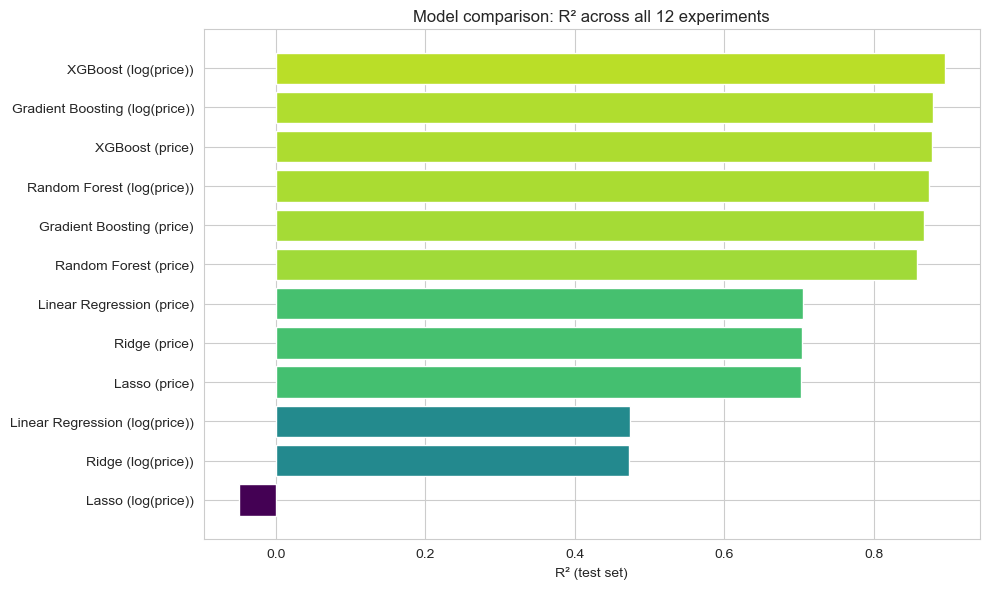

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = results_df.copy()
plot_df['label'] = plot_df['Model'] + ' (' + plot_df['Target'] + ')'
plot_df = plot_df.sort_values('R2')
ax.barh(plot_df['label'], plot_df['R2'], color=plt.cm.viridis(plot_df['R2']))
ax.set_xlabel('R² (test set)')
ax.set_title('Model comparison: R² across all 12 experiments')
plt.tight_layout()
plt.show()

### Takeaways from the model comparison
- Plain **Linear Regression / Ridge / Lasso** all land around **R² ≈ 0.70** — the relationship
  between features and price is not fully linear (matches the EDA insight).
- **Tree ensembles** (Random Forest, Gradient Boosting, XGBoost) jump to **R² ≈ 0.86–0.88**,
  confirming non-linear interactions (e.g., location × grade × size) matter.
- Predicting **log(price)** instead of raw price further improves the tree ensembles
  (it stabilizes variance for the right-skewed target) but *hurts* plain linear regression's RMSE.
- **XGBoost on log(price)** is the best performer among the 12 experiments — it's chosen for tuning.

## Hyperparameter Tuning the Best Candidate
Tune `XGBRegressor` on the log-target with a randomized search over depth, learning rate,
subsampling, and regularization, using 5-fold cross-validation.

In [23]:
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [1, 2, 3, 4, 5],
    'learning_rate': [0.01, 0.02, 0.06, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8],
    'min_child_weight': [1, 2, 3],
}

search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=25,
    scoring='neg_mean_absolute_error',
    cv=KFold(5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, np.log1p(y_train))
print('Best params:', search.best_params_)

Best params: {'subsample': 0.7, 'n_estimators': 400, 'min_child_weight': 2, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [24]:
param_dist = {
    'n_estimators': [200, 300, 500, 800],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=25,
    scoring='neg_mean_absolute_error',
    cv=KFold(5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, np.log1p(y_train))
print('Best params:', search.best_params_)

Best params: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [25]:
best_model = search.best_estimator_
pred = np.expm1(best_model.predict(X_test))

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)
print(f'Tuned XGBoost (log target) -> MAE: ${mae:,.0f}   RMSE: ${rmse:,.0f}   R2: {r2:.4f}')

results_df = pd.concat([results_df, pd.DataFrame([{
    'Model': 'XGBoost (tuned)', 'Target': 'log(price)', 'MAE': mae, 'RMSE': rmse, 'R2': r2
}])], ignore_index=True)
results_df.sort_values('MAE')

Tuned XGBoost (log target) -> MAE: $64,937   RMSE: $120,232   R2: 0.9044


,Model,Target,MAE,RMSE,R2
12,XGBoost (tuned),log(price),"64,937.02","120,231.66",0.90
0,XGBoost,log(price),"68,244.87","125,934.45",0.90
1,XGBoost,price,"70,435.19","135,753.30",0.88
2,Random Forest,log(price),"72,223.77","138,138.10",0.87
3,Random Forest,price,"72,530.57","146,454.42",0.86
4,Gradient Boosting,log(price),"72,983.85","134,928.05",0.88
5,Gradient Boosting,price,"76,521.01","141,782.98",0.87
6,Linear Regression,log(price),"117,323.10","281,900.65",0.47
7,Ridge,log(price),"117,524.66","282,468.54",0.47
8,Linear Regression,price,"126,827.81","210,975.78",0.71


## Final Model Evaluation
Feature importance and actual-vs-predicted diagnostics for the winning model.

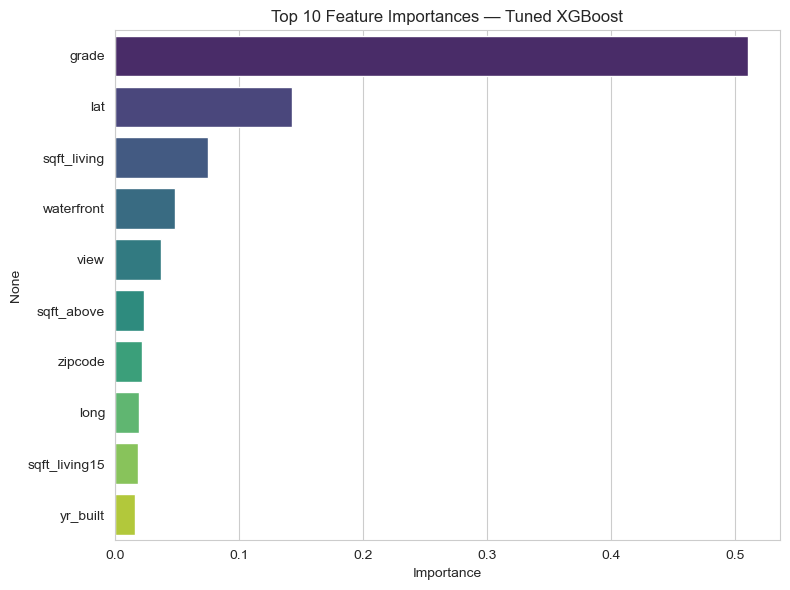

In [26]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index, palette='viridis')
plt.title('Top 10 Feature Importances — Tuned XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

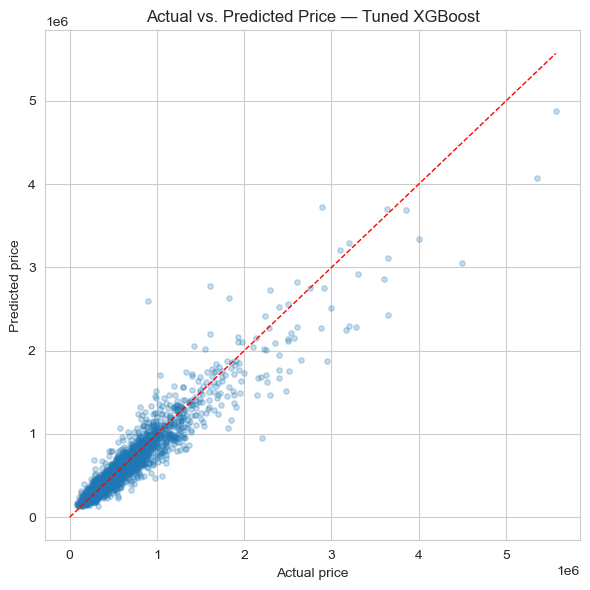

In [27]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, alpha=0.25, s=15)
lims = [0, max(y_test.max(), pred.max())]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs. Predicted Price — Tuned XGBoost')
plt.tight_layout()
plt.show()

## Conclusion
- **Best model: XGBoost Regressor trained on `log(price)`, tuned via RandomizedSearchCV.**
- It roughly **halves the error** of the linear baseline (MAE ≈ \$65K vs. \$127K) and explains
  about **90% of price variance** (R² ≈ 0.90) on held-out data, vs. ~0.70 for linear regression.
- The strongest price drivers are **`grade`** (construction/design quality), **`lat`** (location),
  and **`sqft_living`** — consistent with the EDA and domain intuition.
- Predicting the **log-transformed target** was the single most impactful modeling choice for the
  tree ensembles, directly addressing the right-skew seen during EDA.

## Challenges
- The dataset contained a data quality issue in the `bedrooms` variable (a 33-bedroom outlier),
  which was corrected during cleaning.
- House prices have a highly skewed distribution, motivating the log-target experiments.
- Some features (e.g., `sqft_above` vs. `sqft_living`) are collinear, which affects linear models
  more than tree ensembles.
- Real estate prices are influenced by location and market factors (school zones, nearby
  amenities) not fully captured by this dataset.
- **Next steps:** try target/geospatial encoding for `zipcode`, add polynomial/interaction terms
  for the linear baseline, and validate with a time-based split since sales span multiple months.